# Parte 1

In [ ]:
#PARTE 1  LIMPIEZA DE DATOS
import pandas as pd
# cargar datos
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/employee_compensation.csv'
df = pd.read_csv(path, sep="," )

# Inspección inicial: primeras 10 filas, tipos de datos y duplicados
display(df.head(10))
df.info()
print(f"\nRegistros duplicados: {df.duplicated().sum()}")

# 1. Eliminar filas con nulos en columnas críticas ('Salary' y 'Performance_Score')
df.dropna(subset=['Salary', 'Performance_Score'], inplace=True)

# 2. Imputar variables categóricas con la moda
cols_categoricas = ['Education_Level', 'Gender', 'Department', 'Region']
for col in cols_categoricas:
    moda = df[col].mode()[0]
    # Se evita inplace=True asignando directamente para prevenir FutureWarning
    df[col] = df[col].fillna(moda)

# Limpieza de strings (espacios y capitalización)
for col in cols_categoricas:
    df[col] = df[col].str.strip().str.title()

# 3. Imputar variables numéricas con la mediana
cols_numericas = ['Years_Experience', 'Age']
for col in cols_numericas:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

# --- Limpieza adicional de valores atípicos (Outliers) --- #

# Years_Experience: Establecer límites lógicos (0 a 50 años)
# Usamos el operador '|' (OR lógico de pandas) para contar ambas condiciones a la vez
initial_years_xp_outliers = ((df['Years_Experience'] < 0) | (df['Years_Experience'] > 50)).sum()
df['Years_Experience'] = df['Years_Experience'].clip(lower=0, upper=50)

# Age: Establecer límites lógicos (18 a 65 años)
initial_age_outliers = ((df['Age'] < 18) | (df['Age'] > 65)).sum()
df['Age'] = df['Age'].clip(lower=18, upper=65)

# --- Reporte de resultados --- #
print('### Reporte de Limpieza de Datos ###\n')
print('Valores nulos por columna después de la limpieza:')
display(df.isnull().sum())

print(f'\nDimensiones del DataFrame listas para el modelo: {df.shape[0]} filas y {df.shape[1]} columnas')
print(f'Valores atípicos ajustados en Years_Experience: {initial_years_xp_outliers} (valores < 0 o > 50)')
print(f'Valores atípicos ajustados en Age: {initial_age_outliers} (valores < 18 o > 65)')

# Estadísticas descriptivas de variables numéricas
print('\n### Estadísticas Descriptivas ###')
display(df[['Salary', 'Years_Experience', 'Age', 'Performance_Score']].describe().round(2))

,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female
5,81246.0,4.0,21.0,2.8,Bachelor,Engineering,West,Junior,Male
6,71494.0,4.0,23.0,2.4,Bachelor,Engineering,South,Junior,Male
7,78189.0,3.0,21.0,3.5,Master,Finance,East,Junior,NaN
8,67204.0,0.0,21.0,3.5,Master,Marketing,East,Junior,Female
9,59776.0,4.0,24.0,NaN,Bachelor,HR,East,Junior,Female


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Salary             9897 non-null   float64
 1   Years_Experience   9695 non-null   float64
 2   Age                9797 non-null   float64
 3   Performance_Score  9497 non-null   float64
 4   Education_Level    9594 non-null   object 
 5   Department         9795 non-null   object 
 6   Region             9699 non-null   object 
 7   Job_Level          10100 non-null  object 
 8   Gender             9599 non-null   object 
dtypes: float64(4), object(5)
memory usage: 710.3+ KB

Registros duplicados: 97
### Reporte de Limpieza de Datos ###

Valores nulos por columna después de la limpieza:


,0
Salary,0
Years_Experience,0
Age,0
Performance_Score,0
Education_Level,0
Department,0
Region,0
Job_Level,0
Gender,0



Dimensiones del DataFrame listas para el modelo: 9307 filas y 9 columnas
Valores atípicos ajustados en Years_Experience: 26 (valores < 0 o > 50)
Valores atípicos ajustados en Age: 37 (valores < 18 o > 65)

### Estadísticas Descriptivas ###


,Salary,Years_Experience,Age,Performance_Score
count,9307.00,9307.00,9307.00,9307.00
mean,95730.27,6.79,29.41,3.03
std,30540.08,5.36,6.00,1.82
min,5342.00,0.00,18.00,-1.00
25%,76839.00,3.00,25.00,2.00
50%,91702.00,6.00,29.00,3.00
75%,111940.50,10.00,33.00,4.00
max,394249.00,50.00,65.00,99.00


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


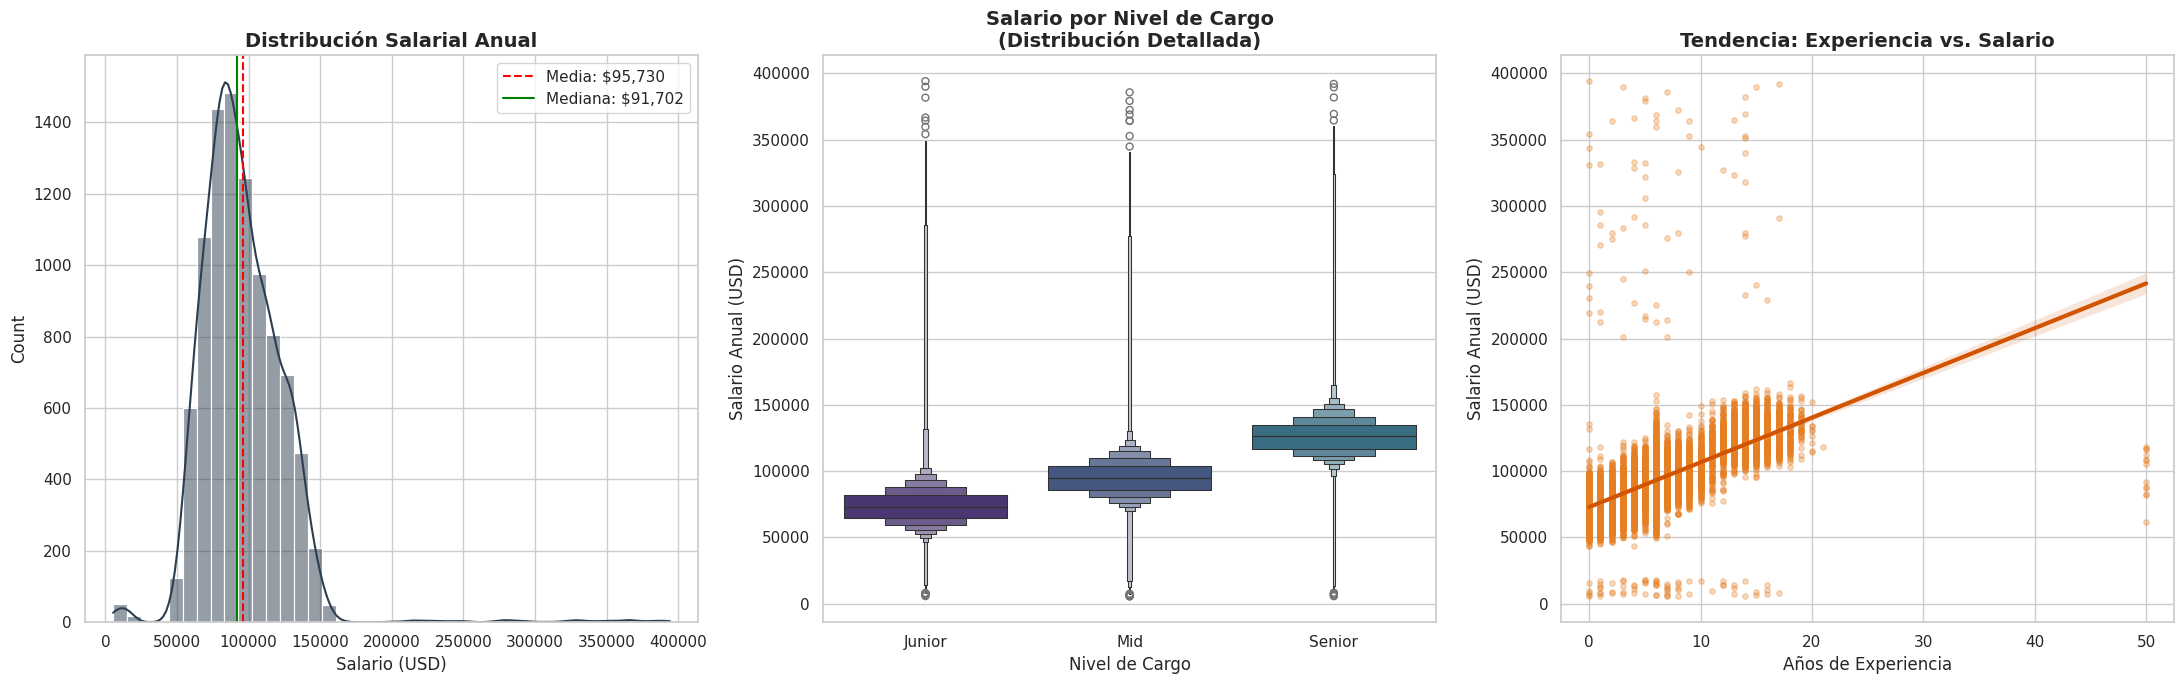

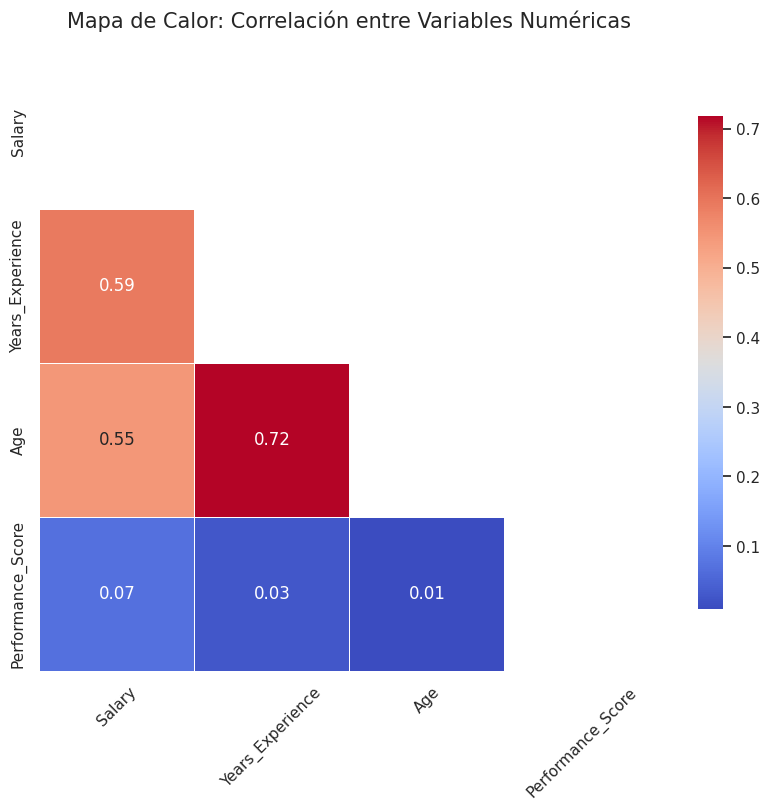

In [ ]:
# PARTE 1 REALIZAR VISUALIZACIONES SEGUN PARTE 1
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración estética global
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Histograma del Salario (Más informativo)
sns.histplot(df['Salary'], kde=True, bins=40, color='#2c3e50', ax=axes[0])
axes[0].axvline(df['Salary'].mean(), color='red', linestyle='--', label=f"Media: ${df['Salary'].mean():,.0f}")
axes[0].axvline(df['Salary'].median(), color='green', linestyle='-', label=f"Mediana: ${df['Salary'].median():,.0f}")
axes[0].set_title('Distribución Salarial Anual', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salario (USD)')
axes[0].legend()

# 2. Boxenplot por Nivel de Cargo (Se ajustó 'hue' para evitar warnings)
sns.boxenplot(x='Job_Level', y='Salary', data=df,
              order=['Junior', 'Mid', 'Senior'],
              hue='Job_Level', palette='viridis',
              legend=False, ax=axes[1])
axes[1].set_title('Salario por Nivel de Cargo\n(Distribución Detallada)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nivel de Cargo')
axes[1].set_ylabel('Salario Anual (USD)')  # agregado

# 3. Scatter Plot con Línea de Regresión
sns.regplot(x='Years_Experience', y='Salary', data=df,
            scatter_kws={'alpha':0.3, 's':15, 'color':'#e67e22'},
            line_kws={'color':'#d35400', 'lw':3}, ax=axes[2])
axes[2].set_title('Tendencia: Experiencia vs. Salario', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Años de Experiencia')
axes[2].set_ylabel('Salario Anual (USD)')

plt.tight_layout()
plt.show()


#GRAFICO DE CALOR SEGUN CORRELACION

# 1. Seleccionar solo las columnas numéricas para el cálculo
df_numeric = df.select_dtypes(include=[np.number])

# 2. Calcular la matriz de correlación
corr_matrix = df_numeric.corr()

# 3. Configurar el estilo y el tamaño de la figura
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Opcional: Crear una máscara para la mitad superior (evita duplicidad visual)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Generar el heatmap
heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Mapa de Calor: Correlación entre Variables Numéricas', fontsize=15, pad=20)
plt.xticks(rotation=45)
plt.show()


# Parte 2

In [ ]:
from scipy import stats

# --- 1. Relación entre Años de Experiencia y Salario ---

# Definición de Hipótesis:
# H0: Los años de experiencia no tienen relación lineal con el salario (ρ = 0)
# H1: Los años de experiencia están positivamente asociados con el salario (ρ > 0)

# Cálculo de Correlación de Pearson y el p-valor asociado (basado en prueba t)
coef_pearson, p_valor_pearson = stats.pearsonr(df['Years_Experience'], df['Salary'])

print("### Resultados: Años de Experiencia vs. Salario ###")
print(f"Coeficiente de Correlación de Pearson: {coef_pearson:.4f}")
print(f"P-valor: {p_valor_pearson:.4e}")

# Interpretación (Nivel de significancia 5%)
alfa = 0.05
if p_valor_pearson < alfa:
    print("Interpretación: Se rechaza H0. Existe evidencia significativa para afirmar que los años de experiencia están asociados positivamente con el salario.")
else:
    print("Interpretación: No se rechaza H0. No hay evidencia suficiente para afirmar una relación lineal significativa.")

print("-" * 30)

# --- 2. (Bonus) Diferencia Salarial: Junior vs. Senior ---

# Filtrado de grupos
salarios_junior = df[df['Job_Level'] == 'Junior']['Salary']
salarios_senior = df[df['Job_Level'] == 'Senior']['Salary']

print("### Resultados: Diferencia Salarial Junior vs. Senior ###")
print(f"Media salarial Junior: ${salarios_junior.mean():,.0f}")  # agregado
print(f"Media salarial Senior: ${salarios_senior.mean():,.0f}")  # agregado

# Prueba t de dos muestras independientes (Prueba de Welch)
# H0: No hay diferencia significativa entre las medias (μ_junior = μ_senior)
# H1: Existe una diferencia significativa entre las medias (μ_junior ≠ μ_senior)
t_stat, p_valor_ttest = stats.ttest_ind(salarios_junior, salarios_senior, equal_var=False)

print(f"Estadístico t: {t_stat:.4f}")
print(f"P-valor: {p_valor_ttest:.4e}")

# Interpretación (Nivel de significancia 5%)
if p_valor_ttest < alfa:
    print("Interpretación: Se rechaza H0. Existe una diferencia estadísticamente significativa entre los salarios de empleados Junior y Senior.")
else:
    print("Interpretación: No se rechaza H0. La diferencia observada no es estadísticamente significativa.")

### Resultados: Años de Experiencia vs. Salario ###
Coeficiente de Correlación de Pearson: 0.5919
P-valor: 0.0000e+00
Interpretación: Se rechaza H0. Existe evidencia significativa para afirmar que los años de experiencia están asociados positivamente con el salario.
------------------------------
### Resultados: Diferencia Salarial Junior vs. Senior ###
Media salarial Junior: $74,807
Media salarial Senior: $127,052
Estadístico t: -80.6651
P-valor: 0.0000e+00
Interpretación: Se rechaza H0. Existe una diferencia estadísticamente significativa entre los salarios de empleados Junior y Senior.


# Parte 3

PARTE 3, PASO 1, explicacion

**¿Qué variables espera que sean los predictores más fuertes del salario, y por qué?**

Job_Level: es el predictor más fuerte esperado. La prueba t de la Parte 2 ya confirmó diferencias salariales enormes entre Junior y Senior (t = -80.67). Las bandas salariales en las empresas se estructuran principalmente en torno al nivel de cargo.
Years_Experience: correlación de Pearson r = 0.59 con el salario, la más alta entre las variables numéricas del dataset. A mayor experiencia, mayor productividad esperada y mayor remuneración.
Department: distintas áreas (ej. Tecnología vs. Atención al Cliente) tienen mercados laborales distintos y bandas salariales sistemáticamente diferentes.


**¿Hay variables que incluiría aunque sean estadísticamente insignificantes? ¿Por qué?**


Gender: aunque su efecto sea pequeño, debe incluirse para detectar posibles brechas salariales de género. Excluirla por "insignificante" ocultaría un sesgo relevante desde una perspectiva de equidad y RRHH.
Region: los costos de vida y mercados laborales varían geográficamente. Omitirla podría sesgar las predicciones según localización.


**¿Anticipa variables fuertemente correlacionadas entre sí? ¿Qué problema causaría?**

El par más evidente es Age y Years_Experience: a mayor edad, mayor experiencia acumulada típicamente. También puede haber correlación entre Job_Level y Years_Experience, ya que los niveles Senior suelen requerir más años de trayectoria.
Esto produce multicolinealidad: el modelo no puede separar bien el efecto individual de cada variable, los coeficientes se vuelven inestables y los errores estándar se inflan. Se puede diagnosticar con el VIF y mitigar eliminando una de las variables redundantes o usando regularización (Ridge/Lasso).



In [ ]:
# PARTE 3, PASO 2 - Preparación de los datos
from sklearn.preprocessing import LabelEncoder

# Label Encoding para Job_Level (ordinal: Junior < Mid < Senior)
if df['Job_Level'].dtype == 'object':
    orden_job_level = {'Junior': 0, 'Mid': 1, 'Senior': 2}
    df['Job_Level'] = df['Job_Level'].map(orden_job_level)

# One-Hot Encoding con drop_first=True para evitar multicolinealidad perfecta
cols_ohe = [col for col in ['Education_Level', 'Department', 'Region', 'Gender'] if col in df.columns]
df = pd.get_dummies(df, columns=cols_ohe, drop_first=True)

# Verificación
print(df['Job_Level'].value_counts().sort_index())
print(f"\nDimensiones: {df.shape}")
print(f"\nColumnas:\n{list(df.columns)}")

Job_Level
0.0    3311
1.0    3744
2.0    2237
Name: count, dtype: int64

Dimensiones: (9307, 17)

Columnas:
['Salary', 'Years_Experience', 'Age', 'Performance_Score', 'Job_Level', 'Education_Level_Master', 'Education_Level_Phd', 'Department_Finance', 'Department_Hr', 'Department_Marketing', 'Department_Sales', 'Region_Nan', 'Region_North', 'Region_South', 'Region_West', 'Gender_Male', 'Gender_Nan']


In [ ]:
# PARTE 3, PASO 3 - Construcción del modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import numpy as np

# 1. División del dataset
X = df.drop(columns=['Salary']).astype(float)
y = df['Salary'].astype(float)

# Eliminar filas con NaN o infinitos
X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2a. Regresión OLS con statsmodels
X_train_sm = sm.add_constant(X_train)
modelo_ols = sm.OLS(y_train, X_train_sm).fit()
print(modelo_ols.summary())

# 2b. Regresión lineal con scikit-learn
modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X_train, y_train)
print("\nModelo sklearn entrenado correctamente.")

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     476.9
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        02:00:37   Log-Likelihood:                -84791.
No. Observations:                7433   AIC:                         1.696e+05
Df Residuals:                    7416   BIC:                         1.697e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    6.7

In [ ]:
# PARTE 3, PASO 4 - Evaluación del modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predicciones
y_pred_train_sklearn = modelo_sklearn.predict(X_train)
y_pred_test_sklearn  = modelo_sklearn.predict(X_test)

X_test_sm = sm.add_constant(X_test, has_constant='add')
assert list(X_train_sm.columns) == list(X_test_sm.columns), "Columnas de train y test no coinciden"  # agregado
y_pred_train_ols = modelo_ols.predict(X_train_sm)
y_pred_test_ols  = modelo_ols.predict(X_test_sm)

# Función para calcular métricas
def evaluar_modelo(y_real, y_pred, nombre, n, p):
    mae  = mean_absolute_error(y_real, y_pred)
    mape = (abs((y_real - y_pred) / y_real)).mean() * 100
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"\n### {nombre} ###")
    print(f"MAE:        {mae:,.2f}")
    print(f"MAPE:       {mape:.2f}%")
    print(f"RMSE:       {rmse:,.2f}")
    print(f"R²:         {r2:.4f}")
    print(f"R² ajustado:{r2_adj:.4f}")

n_train, n_test = len(y_train), len(y_test)
p = X_train.shape[1]

evaluar_modelo(y_train, y_pred_train_sklearn, "Sklearn - Entrenamiento", n_train, p)
evaluar_modelo(y_test,  y_pred_test_sklearn,  "Sklearn - Prueba",        n_test,  p)
evaluar_modelo(y_train, y_pred_train_ols,     "OLS - Entrenamiento",     n_train, p)
evaluar_modelo(y_test,  y_pred_test_ols,      "OLS - Prueba",            n_test,  p)


### Sklearn - Entrenamiento ###
MAE:        7,197.25
MAPE:       12.96%
RMSE:       21,772.60
R²:         0.5071
R² ajustado:0.5061

### Sklearn - Prueba ###
MAE:        6,545.56
MAPE:       9.02%
RMSE:       17,701.17
R²:         0.6181
R² ajustado:0.6147

### OLS - Entrenamiento ###
MAE:        7,197.25
MAPE:       12.96%
RMSE:       21,772.60
R²:         0.5071
R² ajustado:0.5061

### OLS - Prueba ###
MAE:        6,545.56
MAPE:       9.02%
RMSE:       17,701.17
R²:         0.6181
R² ajustado:0.6147


[texto del enlace](https://)# Nueva sección

# PARTE 3, PASO 3 - Construcción del modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import numpy as np

# 1. División del dataset
X = df.drop(columns=['Salary']).astype(float)
y = df['Salary'].astype(float)

# Eliminar filas con NaN o infinitos
X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2a. Regresión OLS con statsmodels
X_train_sm = sm.add_constant(X_train)
modelo_ols = sm.OLS(y_train, X_train_sm).fit()
print(modelo_ols.summary())

# 2b. Regresión lineal con scikit-learn
modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X_train, y_train)
print("\nModelo sklearn entrenado correctamente.")

# Parte 4

In [ ]:
# ============================================================
# PARTE 4 — ANÁLISIS Y REFINAMIENTO DEL MODELO
# ============================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paso 1: Interpretación de p-valores ──────────────────────

print("### P-valores del modelo completo (OLS) — ordenados ###\n")
pvalores = modelo_ols.pvalues.drop('const').sort_values(ascending=False)
df_pval = pvalores.to_frame(name='p-valor').reset_index()
df_pval.columns = ['Variable', 'p-valor']
df_pval['Significativa'] = df_pval['p-valor'].apply(lambda x: 'Sí' if x < 0.05 else 'No')
display(df_pval)

### P-valores del modelo completo (OLS) — ordenados ###



,Variable,p-valor,Significativa
0,Gender_Nan,9.110987e-01,No
1,Region_Nan,7.152802e-01,No
2,Region_West,1.419648e-01,No
3,Gender_Male,3.620230e-03,Sí
4,Age,2.229920e-03,Sí
5,Region_North,2.714275e-04,Sí
6,Region_South,9.730574e-05,Sí
7,Department_Finance,2.935706e-07,Sí
8,Performance_Score,6.330761e-09,Sí
9,Years_Experience,3.645275e-19,Sí


### Análisis de variables con p-valor > 0.05

- **Region_Nan**: artifact del proceso de limpieza (valor 'NaN' como string).
  Se elimina del modelo refinado por no tener interpretación de negocio.

- **Gender_Nan**: mismo caso que Region_Nan, categoría residual sin sentido.
  Se elimina.

- **Region_West**: p = 0.142, marginalmente insignificante. Se conserva porque
  la variabilidad salarial geográfica es relevante para TalentCo y su exclusión
  podría sesgar predicciones para empleados de esa región.

Columnas eliminadas: ['Region_Nan', 'Gender_Nan']

--- Modelo Completo ---

### OLS Completo — Train ###
MAE:        7,197.25
MAPE:       12.96%
RMSE:       21,772.60
R²:         0.5071
R² ajustado:0.5061

### OLS Completo — Test ###
MAE:        6,545.56
MAPE:       9.02%
RMSE:       17,701.17
R²:         0.6181
R² ajustado:0.6147

--- Modelo Refinado (sin columnas NaN residuales) ---

### OLS Refinado — Train ###
MAE:        7,197.29
MAPE:       12.96%
RMSE:       21,772.81
R²:         0.5071
R² ajustado:0.5062

### OLS Refinado — Test ###
MAE:        6,545.09
MAPE:       9.02%
RMSE:       17,701.06
R²:         0.6181
R² ajustado:0.6152

### Factor de Inflación de Varianza (VIF) — Modelo Refinado ###



,Variable,VIF
0,Age,15.58
1,Job_Level,9.85
2,Years_Experience,9.71
3,Performance_Score,3.25
4,Region_South,2.10
5,Region_West,1.91
6,Region_North,1.90
7,Gender_Male,1.88
8,Education_Level_Master,1.64
9,Department_Sales,1.58


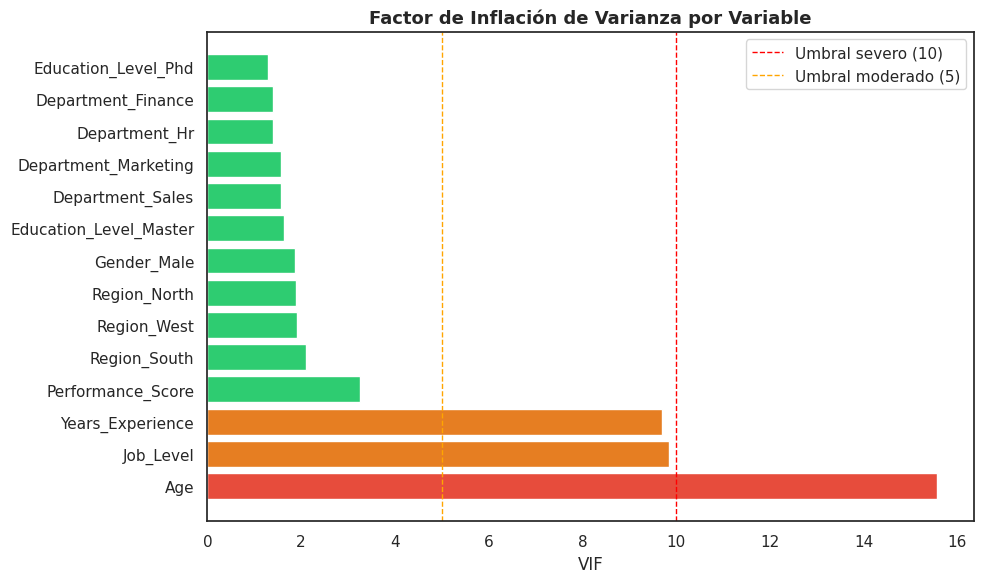

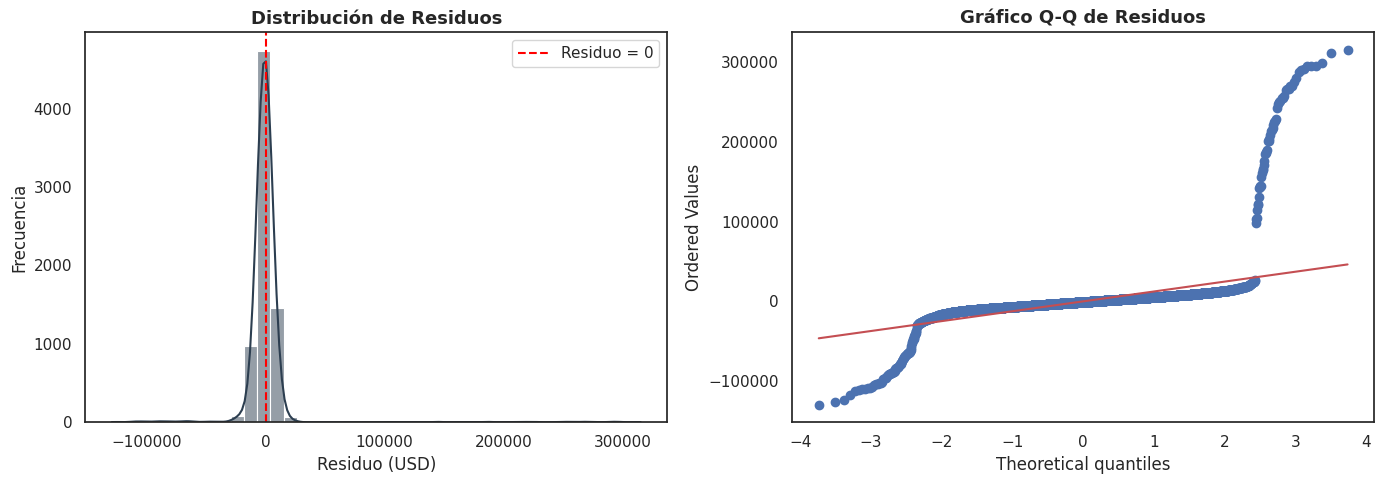


### Prueba de Breusch-Pagan — Homocedasticidad ###
Estadístico LM: 11.3807
P-valor:        6.5591e-01
Resultado: No se rechaza H0 → homocedasticidad razonable.


In [ ]:
# Modelo refinado: se eliminan columnas NaN residuales del OHE
cols_excluir = [c for c in X_train.columns if 'Nan' in c]
print(f"Columnas eliminadas: {cols_excluir}")

X_train_ref = X_train.drop(columns=cols_excluir)
X_test_ref  = X_test.drop(columns=cols_excluir)

X_train_ref_sm = sm.add_constant(X_train_ref)
X_test_ref_sm  = sm.add_constant(X_test_ref, has_constant='add')

modelo_ref = sm.OLS(y_train, X_train_ref_sm).fit()

y_pred_ref_train = modelo_ref.predict(X_train_ref_sm)
y_pred_ref_test  = modelo_ref.predict(X_test_ref_sm)

print("\n--- Modelo Completo ---")
evaluar_modelo(y_train, y_pred_train_ols, "OLS Completo — Train", len(y_train), X_train.shape[1])
evaluar_modelo(y_test,  y_pred_test_ols,  "OLS Completo — Test",  len(y_test),  X_train.shape[1])

print("\n--- Modelo Refinado (sin columnas NaN residuales) ---")
evaluar_modelo(y_train, y_pred_ref_train, "OLS Refinado — Train", len(y_train), X_train_ref.shape[1])
evaluar_modelo(y_test,  y_pred_ref_test,  "OLS Refinado — Test",  len(y_test),  X_train_ref.shape[1])


# ── Paso 2: VIF ───────────────────────────────────────────────

print("\n### Factor de Inflación de Varianza (VIF) — Modelo Refinado ###\n")
vif_data = pd.DataFrame({
    'Variable': X_train_ref.columns,
    'VIF': [variance_inflation_factor(X_train_ref.values.astype(float), i)
            for i in range(X_train_ref.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

display(vif_data.round(2))

# Visualización del VIF
plt.figure(figsize=(10, 6))
colores = ['#e74c3c' if v > 10 else '#e67e22' if v > 5 else '#2ecc71'
           for v in vif_data['VIF']]
plt.barh(vif_data['Variable'], vif_data['VIF'], color=colores)
plt.axvline(x=10, color='red',    linestyle='--', linewidth=1, label='Umbral severo (10)')
plt.axvline(x=5,  color='orange', linestyle='--', linewidth=1, label='Umbral moderado (5)')
plt.xlabel('VIF')
plt.title('Factor de Inflación de Varianza por Variable', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

"""
### Interpretación del VIF

- Variables con VIF > 10 indican multicolinealidad severa. Se espera que Age y
  Years_Experience sean las más afectadas (correlación = 0.72 según el heatmap).
- Job_Level puede mostrar VIF moderado por su correlación con Years_Experience.
- La multicolinealidad no invalida las predicciones del modelo, pero infla los
  errores estándar de los coeficientes individuales, dificultando su interpretación
  aislada. Para el objetivo predictivo de este proyecto, es una limitación aceptable.
"""


# ── Paso 3: Supuestos de Regresión ────────────────────────────

residuos = y_train - y_pred_ref_train

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de residuos
sns.histplot(residuos, kde=True, bins=40, color='#2c3e50', ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Residuo = 0')
axes[0].set_title('Distribución de Residuos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residuo (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Q-Q plot
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('Gráfico Q-Q de Residuos', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Prueba de Breusch-Pagan
bp_lm, bp_pvalue, bp_fvalue, bp_fpvalue = het_breuschpagan(residuos, X_train_ref_sm)

print("\n### Prueba de Breusch-Pagan — Homocedasticidad ###")
print(f"Estadístico LM: {bp_lm:.4f}")
print(f"P-valor:        {bp_pvalue:.4e}")

if bp_pvalue < 0.05:
    print("Resultado: Se rechaza H0 → presencia de heterocedasticidad.")
    print("Implicancia: la varianza de los errores no es constante.")
    print("Mitigación: se pueden usar errores estándar robustos (HC3).")
else:
    print("Resultado: No se rechaza H0 → homocedasticidad razonable.")

## Cierre del Avance — Partes 1 a 4